In [39]:
import inspect
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
import seaborn as sns
import seaborn.objects as so
from more_itertools import powerset

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "GeoPAS_v1").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")

PROJECT_ROOT = Path(
    os.environ.get("PROJECT_ROOT", os.environ.get("GEOPAS_PROJECT_ROOT", str(find_project_root(Path.cwd().resolve()))))
).resolve()
RELERT_PATH = Path(
    os.environ.get("RELERT_CSV", str(PROJECT_ROOT / "data" / "bbob_by_deepela" / "relert.csv"))
).resolve()

relert = pd.read_csv(RELERT_PATH)
print(f"Loaded relERT from: {RELERT_PATH}")

relert

Loaded relERT from: /data1/home/jw1017/AS_BBO_REBUILT/data/bbob_by_deepela/relert.csv


,Problem,Dim,BrentSTEPqi_Posik,BrentSTEPrr_Posik,CMA-CSA_Atamna,HCMA_loshchilov_noiseless,HMLSL_pal_noiseless,IPOP400D_auger_noiseless,MCS_huyer_noiseless,M_LSL_pal_noiseless,OQNLP_pal_noiseless,SMAC-BBOB_hutter_noiseless,fmincon_pal_noiseless,fminunc_pal_noiseless
0,f1,2,1.766667,1.766667,13.666667,1.000000,1.866667,11.533333,2.600000,1.866667,3.066667,2.400000,1.866667,1.166667
1,f1,3,2.100000,2.100000,20.075000,1.000000,1.925000,16.525000,2.375000,1.925000,2.875000,3.450000,1.925000,1.125000
2,f1,5,2.350000,2.350000,21.116667,1.000000,2.183333,20.716667,2.633333,2.183333,2.516667,3.300000,2.183333,1.083333
3,f1,10,2.428571,2.428571,26.696429,1.000000,2.205357,22.589286,2.232143,2.205357,1.973214,6.544643,2.205357,1.026786
4,f2,2,1.000000,1.252427,17.213592,9.233010,1.951456,22.310680,3.155340,1.951456,2.475728,36690.300000,1.951456,4.475728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,f23,10,36690.300000,36690.300000,29.384524,1.000000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000
92,f24,2,8.327445,36690.300000,36690.300000,183.624168,12.050691,36690.300000,5.607442,5.549027,1.000000,36690.300000,11.981055,3.886329
93,f24,3,36690.300000,36690.300000,36690.300000,249.051339,6.232608,36690.300000,36690.300000,36690.300000,1.000000,36690.300000,36690.300000,36690.300000
94,f24,5,36690.300000,36690.300000,36690.300000,1.000000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000


In [40]:
ALGORITHMS = [
    "BrentSTEPqi_Posik",
    "BrentSTEPrr_Posik",
    "CMA-CSA_Atamna",
    "HCMA_loshchilov_noiseless",
    "HMLSL_pal_noiseless",
    "IPOP400D_auger_noiseless",
    "MCS_huyer_noiseless",
    "M_LSL_pal_noiseless",
    "OQNLP_pal_noiseless",
    "SMAC-BBOB_hutter_noiseless",
    "fmincon_pal_noiseless",
    "fminunc_pal_noiseless",
]

performance_df = relert.copy()
performance_df.loc[:, ALGORITHMS] = performance_df.loc[:, ALGORITHMS]
performance_df["picked_algo"] = performance_df[ALGORITHMS].idxmin(axis=1)

performance_df

,Problem,Dim,BrentSTEPqi_Posik,BrentSTEPrr_Posik,CMA-CSA_Atamna,HCMA_loshchilov_noiseless,HMLSL_pal_noiseless,IPOP400D_auger_noiseless,MCS_huyer_noiseless,M_LSL_pal_noiseless,OQNLP_pal_noiseless,SMAC-BBOB_hutter_noiseless,fmincon_pal_noiseless,fminunc_pal_noiseless,picked_algo
0,f1,2,1.766667,1.766667,13.666667,1.000000,1.866667,11.533333,2.600000,1.866667,3.066667,2.400000,1.866667,1.166667,HCMA_loshchilov_noiseless
1,f1,3,2.100000,2.100000,20.075000,1.000000,1.925000,16.525000,2.375000,1.925000,2.875000,3.450000,1.925000,1.125000,HCMA_loshchilov_noiseless
2,f1,5,2.350000,2.350000,21.116667,1.000000,2.183333,20.716667,2.633333,2.183333,2.516667,3.300000,2.183333,1.083333,HCMA_loshchilov_noiseless
3,f1,10,2.428571,2.428571,26.696429,1.000000,2.205357,22.589286,2.232143,2.205357,1.973214,6.544643,2.205357,1.026786,HCMA_loshchilov_noiseless
4,f2,2,1.000000,1.252427,17.213592,9.233010,1.951456,22.310680,3.155340,1.951456,2.475728,36690.300000,1.951456,4.475728,BrentSTEPqi_Posik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,f23,10,36690.300000,36690.300000,29.384524,1.000000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,HCMA_loshchilov_noiseless
92,f24,2,8.327445,36690.300000,36690.300000,183.624168,12.050691,36690.300000,5.607442,5.549027,1.000000,36690.300000,11.981055,3.886329,OQNLP_pal_noiseless
93,f24,3,36690.300000,36690.300000,36690.300000,249.051339,6.232608,36690.300000,36690.300000,36690.300000,1.000000,36690.300000,36690.300000,36690.300000,OQNLP_pal_noiseless
94,f24,5,36690.300000,36690.300000,36690.300000,1.000000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,HCMA_loshchilov_noiseless


In [41]:
relert.loc[:, ALGORITHMS].describe()

,BrentSTEPqi_Posik,BrentSTEPrr_Posik,CMA-CSA_Atamna,HCMA_loshchilov_noiseless,HMLSL_pal_noiseless,IPOP400D_auger_noiseless,MCS_huyer_noiseless,M_LSL_pal_noiseless,OQNLP_pal_noiseless,SMAC-BBOB_hutter_noiseless,fmincon_pal_noiseless,fminunc_pal_noiseless
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,16873.299917,17644.440074,3466.012189,30.373417,3064.260065,11091.938447,11151.016340,10328.806834,9177.884437,29811.446913,9567.365529,10718.844089
std,18325.225912,18364.913689,10742.631568,182.442203,10191.865472,16929.638775,16894.876273,16576.851712,15967.686556,14394.643003,16179.041832,16753.197800
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,16.377318,18.028628,2.678697,1.635707,1.000000,4.968463,3.414432,1.001840,1.503620,36690.300000,1.037336,1.501050
50%,315.784484,568.438628,7.203385,3.438422,2.067395,12.873297,17.054687,2.709022,4.038082,36690.300000,2.502930,6.393125
75%,36690.300000,36690.300000,20.281427,6.192308,9.928910,36690.300000,36690.300000,36690.300000,9219.047672,36690.300000,36690.300000,36690.300000
max,36690.300000,36690.300000,36690.300000,1765.867486,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000,36690.300000


In [42]:
# performance_vbs_sbs = performance_df.copy()
# performance_vbs_sbs['VBS'] = performance_df[ALGORITHMS].max(axis=1)
# performance_vbs_sbs['SBS'] = performance_df[performance_df[ALGORITHMS].mean(axis=0).idxmax()]
# # performance_vbs_sbs['SBS'] = performance_df['modcmaBIPOP']

# # Remove the algorithm columns, leaving only INFO + VBS/SBS
# performance_vbs_sbs = performance_vbs_sbs[INFO + ['VBS', 'SBS']]
# print("Overall VBS and SBS:", performance_vbs_sbs[['VBS', 'SBS']].mean())
# performance_vbs_sbs.groupby('dim')[['VBS', 'SBS']].mean()

In [43]:
# Compare algorithm complementarity through relERT distributions and VBS pick frequency
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Match the plotting treatment used in robustness_over_parameters.ipynb.
PAPER_BG = "#f9f8f5"
AXIS_BG = "#ffffff"
GRID_COLOR = "#d8cec0"
TEXT_COLOR = "#2d2622"
BOX_EDGE_COLOR = "#cbbfab"
PORTFOLIO_CMAP = LinearSegmentedColormap.from_list(
    "as_bbo_portfolio",
    ["#143d4a", "#336c7a", "#7aa7a2", "#d7d3b1", "#f3eadf"],
)
DARKER_PORTFOLIO_CMAP = LinearSegmentedColormap.from_list(
    "as_bbo_portfolio_darker",
    ["#0f2e36", "#2a5468", "#5c8b8f", "#b9b37e", "#d9d5c4"],
)

mpl.rcParams.update(
    {
        "figure.facecolor": PAPER_BG,
        "axes.facecolor": AXIS_BG,
        "axes.edgecolor": AXIS_BG,
        "axes.labelcolor": TEXT_COLOR,
        "axes.titlecolor": TEXT_COLOR,
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,
        "text.color": TEXT_COLOR,
        "font.family": "DejaVu Serif",
        "axes.titlesize": 18,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 140,
        "savefig.dpi": 240,
        "savefig.facecolor": PAPER_BG,
        "savefig.bbox": "tight",
    }
)
sns.set_theme(style="white", context="notebook")


def _build_algo_palette(algo_order):
    if len(algo_order) == 1:
        sampled = [PORTFOLIO_CMAP(0.12)]
    else:
        sampled = [PORTFOLIO_CMAP(position) for position in np.linspace(0.08, 0.92, len(algo_order))]
    return dict(zip(algo_order, sampled))


def _style_axes(ax):
    ax.set_facecolor(AXIS_BG)
    ax.set_axisbelow(True)
    ax.grid(axis="x", color=GRID_COLOR, linewidth=1.0, alpha=0.9)
    ax.grid(axis="y", visible=False)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)


def plot_relERT_dist_and_selection(performance_df):
    # Order algorithms by VBS pick frequency while retaining algorithms with zero picks.
    pick_counts = performance_df["picked_algo"].value_counts().reindex(ALGORITHMS, fill_value=0)
    algo_order = pick_counts.sort_values(ascending=False, kind="stable").index.tolist()

    # Compute selection proportions for the bar chart panel.
    pick_df = (pick_counts.reindex(algo_order) / len(performance_df)).rename("proportion").reset_index()
    pick_df.columns = ["algorithm", "proportion"]

    # Reuse the same teal-to-sand palette family as the robustness notebook.
    algo_palette = _build_algo_palette(algo_order)
    melted = performance_df.melt(
        id_vars="picked_algo",
        value_vars=ALGORITHMS,
        var_name="algorithm",
        value_name="relERT",
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 7.2),
        gridspec_kw={"width_ratios": [2.15, 1.25]},
    )
    fig.patch.set_facecolor(PAPER_BG)

    # Panel A: relERT distributions by algorithm.
    ax = axes[0]
    sns.boxplot(
        data=melted,
        ax=ax,
        y="algorithm",
        x="relERT",
        order=algo_order,
        palette=algo_palette,
        hue="algorithm",
        dodge=False,
        legend=False,
        saturation=1,
        fliersize=3,
        linewidth=1.15,
        boxprops={"edgecolor": BOX_EDGE_COLOR},
        whiskerprops={"color": BOX_EDGE_COLOR, "linewidth": 1.15},
        capprops={"color": BOX_EDGE_COLOR, "linewidth": 1.15},
        medianprops={"color": TEXT_COLOR, "linewidth": 1.4},
        flierprops={
            "markerfacecolor": TEXT_COLOR,
            "markeredgecolor": TEXT_COLOR,
            "markersize": 3,
            "alpha": 0.35,
        },
    )
    _style_axes(ax)
    ax.set_title("relERT by Algorithm", fontsize=15, fontweight="semibold", pad=12)
    ax.set_xlabel("relERT")
    ax.set_ylabel("Algorithm")

    # Panel B: VBS pick frequency using the same ordering and colour mapping.
    ax = axes[1]
    sns.barplot(
        data=pick_df,
        y="algorithm",
        x="proportion",
        order=algo_order,
        ax=ax,
        palette=algo_palette,
        hue="algorithm",
        dodge=False,
        legend=False,
        edgecolor=AXIS_BG,
        linewidth=0.8,
    )
    _style_axes(ax)
    ax.set_title("VBS Frequency", fontsize=15, fontweight="semibold", pad=12)
    ax.set_xlabel("Proportion selected")
    ax.set_ylabel("")
    x_max = max(0.05, float(pick_df["proportion"].max()) * 1.16)
    ax.set_xlim(0, x_max)

    annotation_offset = x_max * 0.02
    for i, (_, row) in enumerate(pick_df.iterrows()):
        ax.text(
            row["proportion"] + annotation_offset,
            i,
            f"{row['proportion']:.1%}",
            va="center",
            fontsize=11,
            color=TEXT_COLOR,
            clip_on=False,
        )

    fig.suptitle(
        "Portfolio Structure: Performance and VBS Behaviour",
        y=1.01,
        fontsize=17,
        fontweight="semibold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

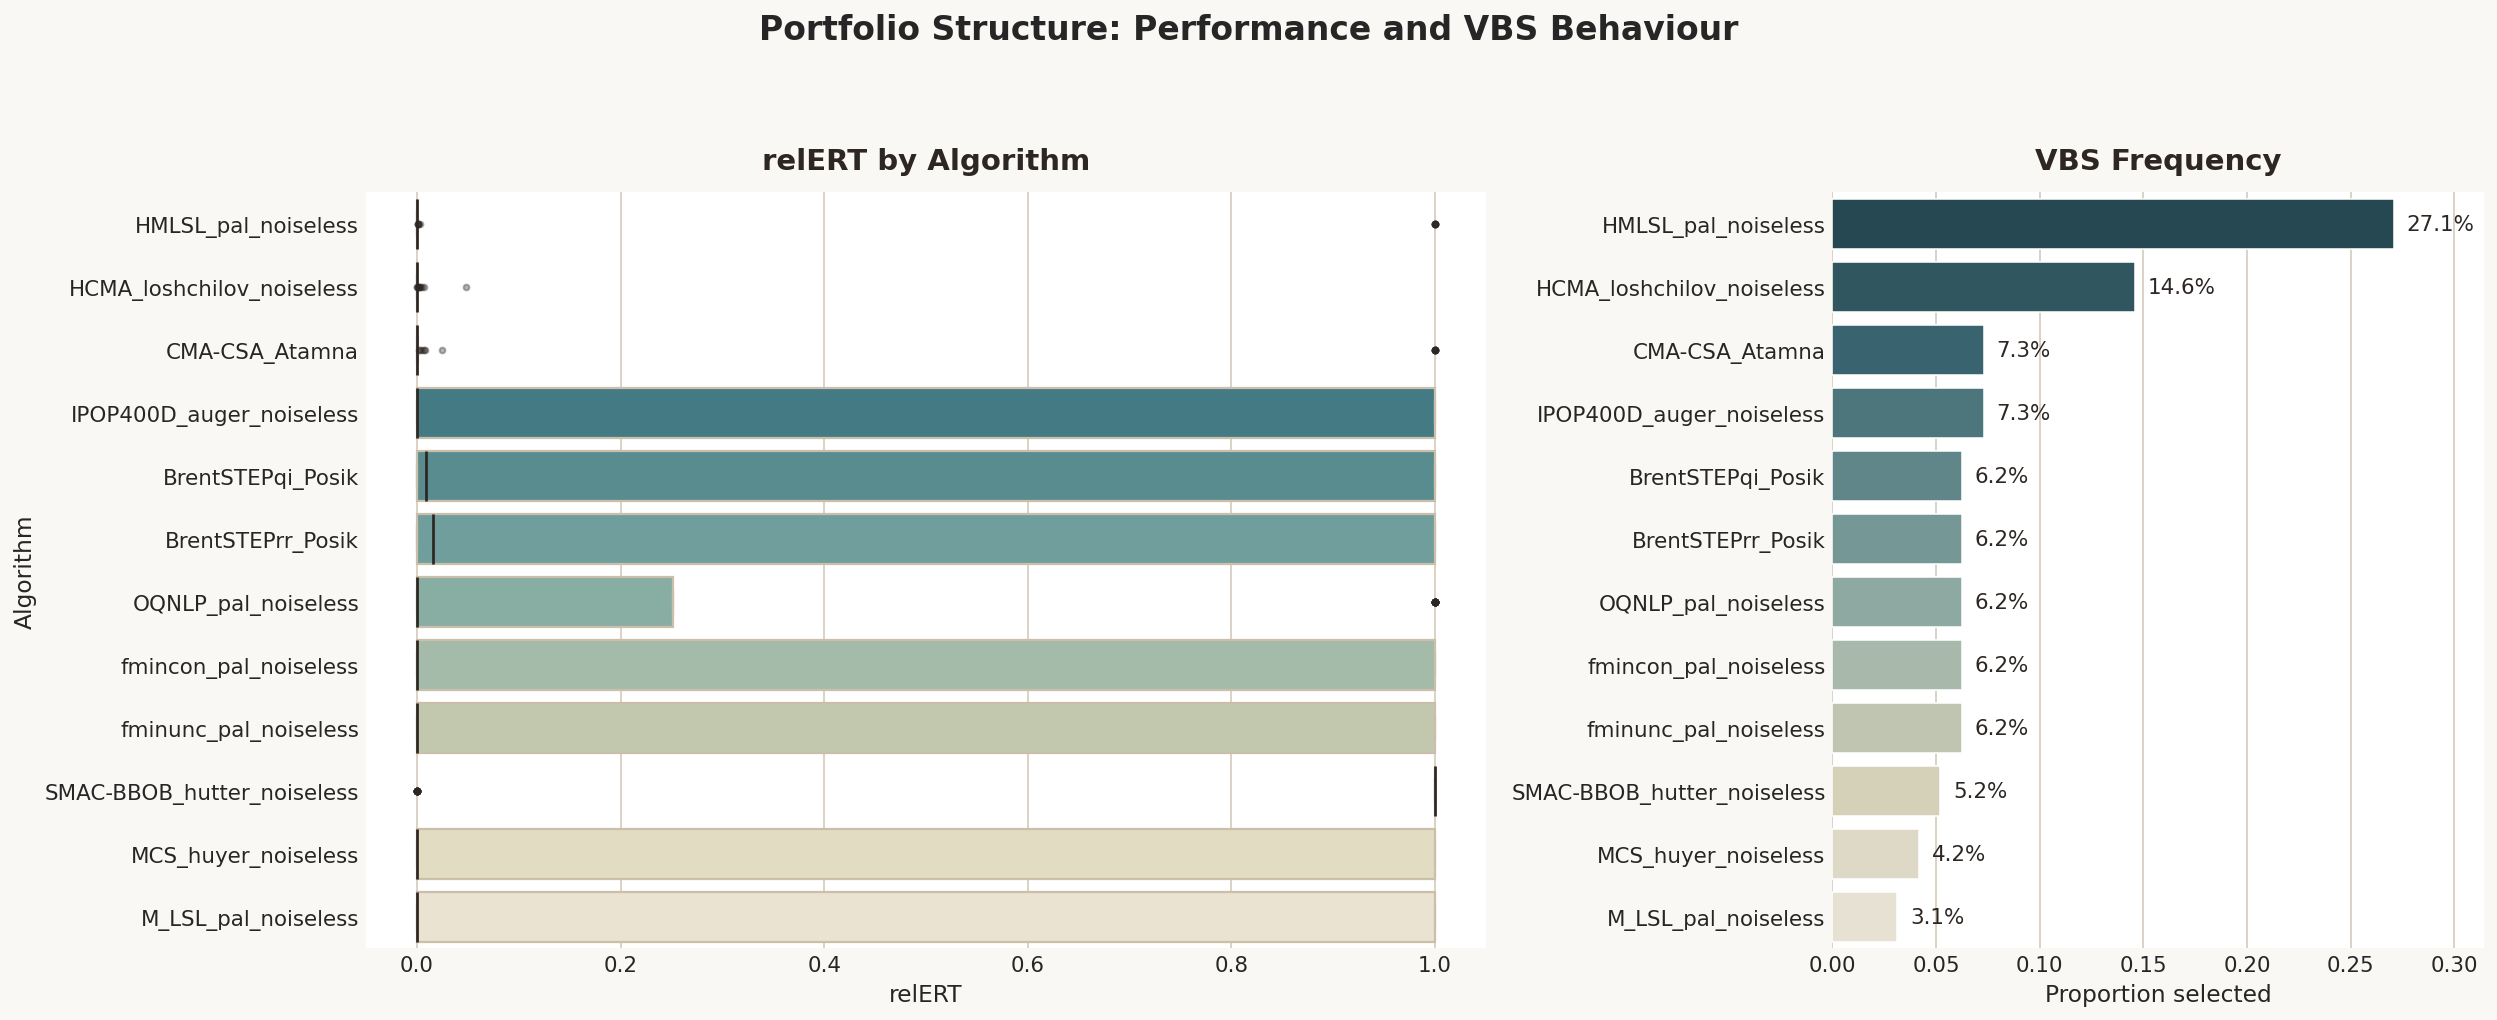

In [44]:
performance_df_norm = performance_df.copy()
performance_df_norm[ALGORITHMS] = (performance_df_norm[ALGORITHMS] - performance_df_norm[ALGORITHMS].min().min()) / (performance_df_norm[ALGORITHMS].max().max() - performance_df_norm[ALGORITHMS].min().min())

# # Plot the boxplots of relERT by algorithm to show the distribution and outliers more explicitly
# plt.figure(figsize=(12, 12))
# sns.boxplot(
#     data=performance_df_norm.melt(
#         id_vars="picked_algo",
#         value_vars=ALGORITHMS,
#         var_name="algorithm",
#         value_name="relERT"
#     ),
#     y="algorithm",
#     x="relERT",
#     order=ALGORITHMS,
#     palette="tab10"
# )
# plt.title("relERT by Algorithm")
# plt.xlabel("Algorithm")
# plt.ylabel("relERT")
# # plt.xticks(rotation=45)
# plt.grid(True, alpha=0.25)
# plt.tight_layout()
# plt.show()

plot_relERT_dist_and_selection(performance_df_norm)

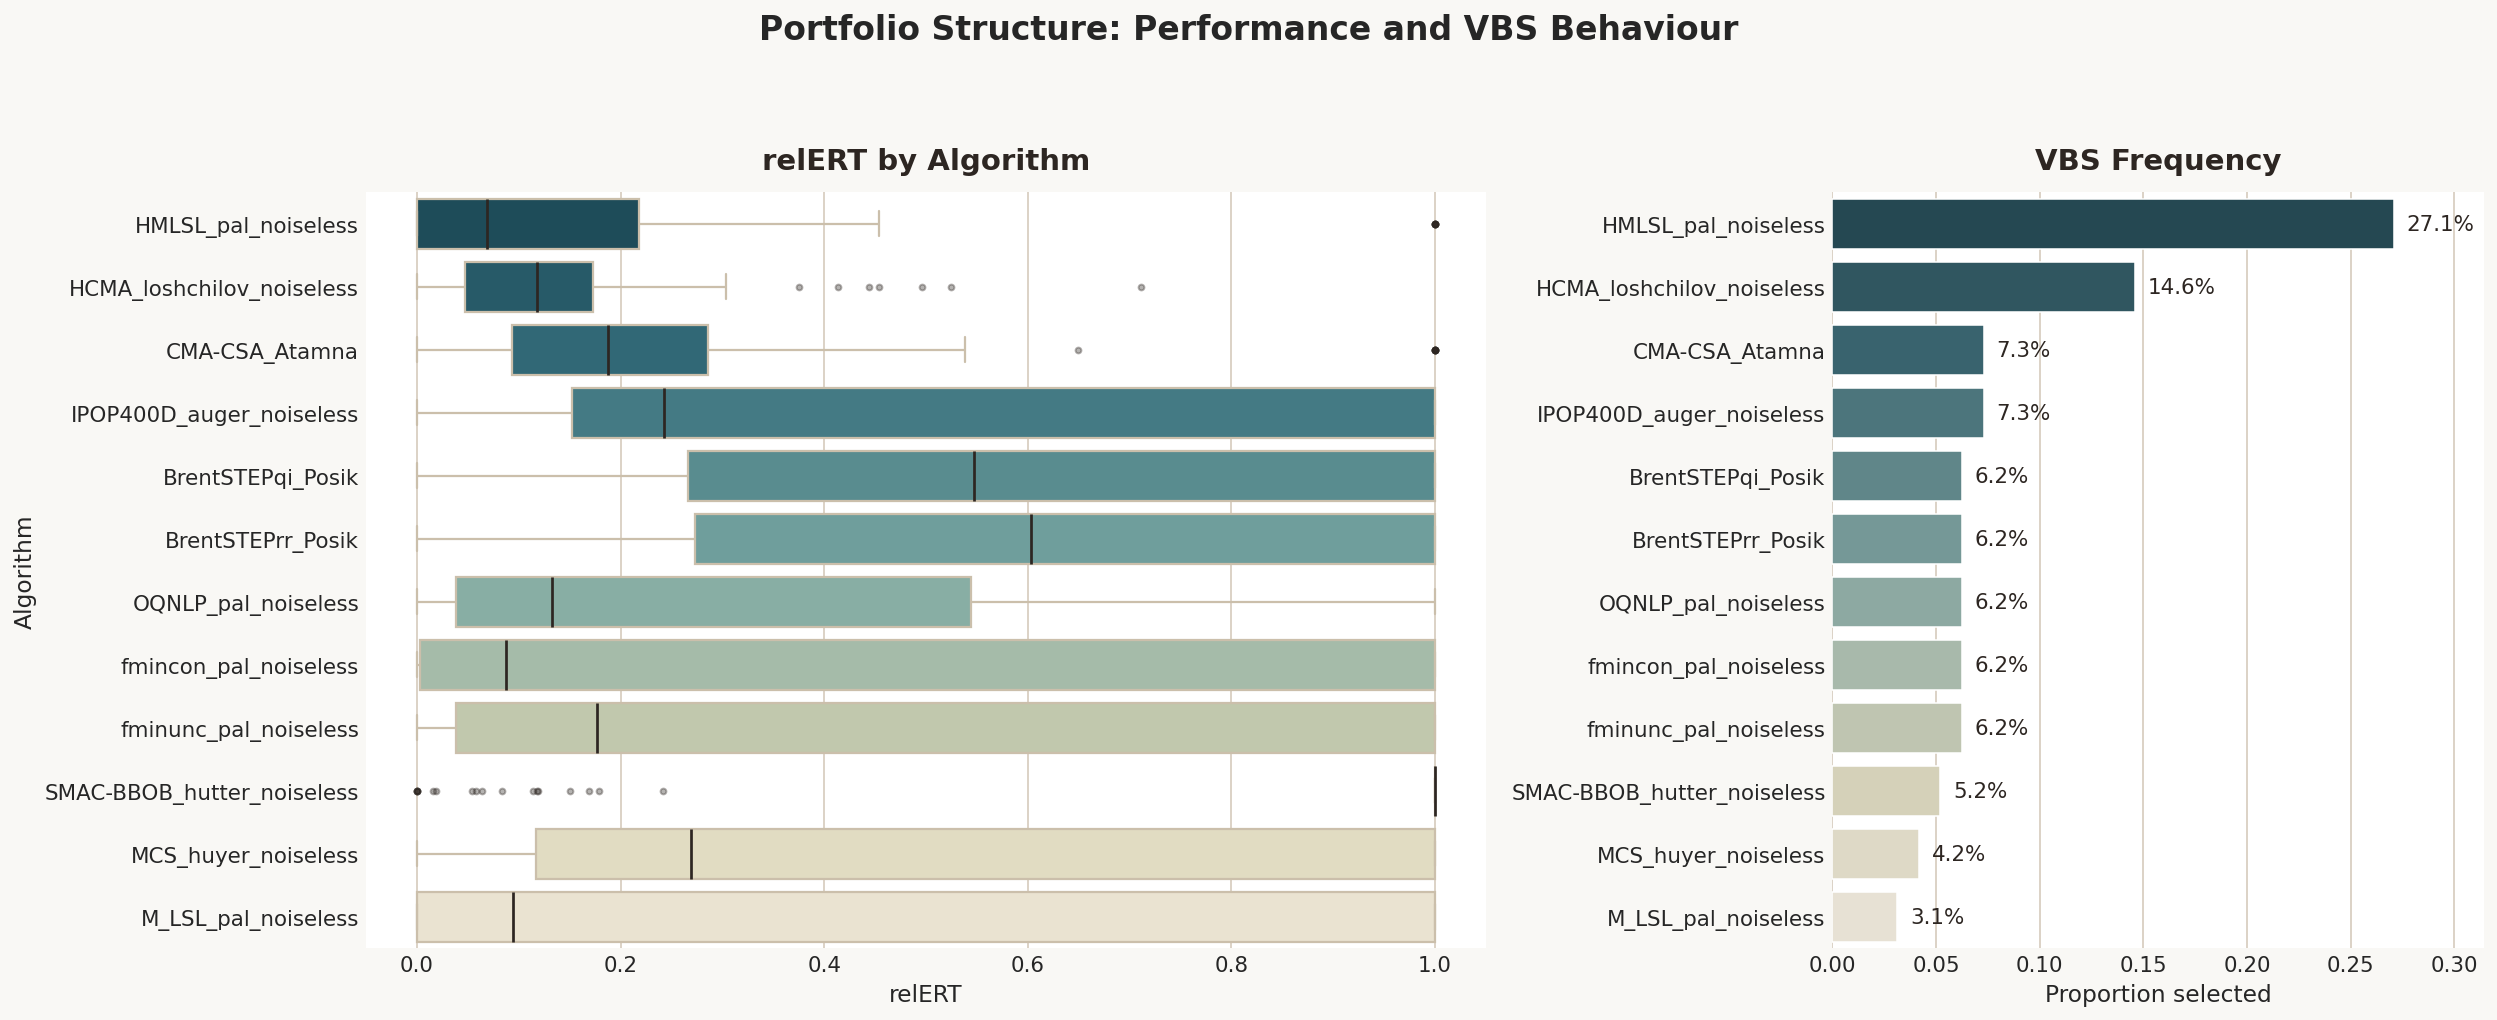

In [45]:
performance_df_log = performance_df.copy()
performance_df_log[ALGORITHMS] = np.log(performance_df_log[ALGORITHMS])
performance_df_log[ALGORITHMS] = (performance_df_log[ALGORITHMS] - performance_df_log[ALGORITHMS].min().min()) / (performance_df_log[ALGORITHMS].max().max() - performance_df_log[ALGORITHMS].min().min())

plot_relERT_dist_and_selection(performance_df_log)

In [46]:
# performance_df_sigmoid_log = performance_df.copy()
# s=1
# performance_df_sigmoid_log[ALGORITHMS] = 1/(1 + np.exp(-(performance_df_sigmoid_log[ALGORITHMS] - np.log(12.477))/s))

# # Plot the boxplots of relERT by algorithm to show the distribution and outliers more explicitly
# plt.figure(figsize=(12, 12))
# sns.boxplot(
#     data=performance_df_sigmoid_log.melt(
#         id_vars="picked_algo",
#         value_vars=ALGORITHMS,
#         var_name="algorithm",
#         value_name="relERT"
#     ),
#     y="algorithm",
#     x="relERT",
#     order=ALGORITHMS,
#     palette="tab10"
# )
# plt.title("relERT by Algorithm")
# plt.xlabel("Algorithm")
# plt.ylabel("relERT")
# # plt.xticks(rotation=45)
# plt.grid(True, alpha=0.25)
# plt.tight_layout()
# plt.show()

# plot_relERT_dist_and_selection(performance_df_sigmoid_log)

In [47]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML


# S_VALUES = np.round(np.linspace(0.1, 2.0, 50), 2)
# SIGMOID_SHIFT = np.log(12.477)

# palette = sns.color_palette("tab10", n_colors=len(ALGORITHMS))
# algo_palette = dict(zip(ALGORITHMS, palette))

# # Monotone transforms preserve ranking; keep baseline selections fixed to avoid tie/rounding drift.
# BASE_PICKED_ALGO = performance_df["picked_algo"].copy()
# BASE_PICK_DF = (
#     BASE_PICKED_ALGO.value_counts().reindex(ALGORITHMS, fill_value=0).div(len(performance_df)).rename("proportion").reset_index()
# )
# BASE_PICK_DF.columns = ["algorithm", "proportion"]

# fig, axes = plt.subplots(
#     1,
#     3,
#     figsize=(22, 7),
#     gridspec_kw={"width_ratios": [2.2, 1.2, 1.2]},
# )


# def _sigmoid_log_transform(df: pd.DataFrame, s: float) -> pd.DataFrame:
#     transformed = df.copy()
#     transformed[ALGORITHMS] = 1 / (1 + np.exp(-(transformed[ALGORITHMS] - SIGMOID_SHIFT) / s))
#     transformed["picked_algo"] = BASE_PICKED_ALGO.values
#     return transformed


# def _draw_frame(s: float) -> None:
#     transformed = _sigmoid_log_transform(performance_df, float(s))

#     for ax in axes:
#         ax.clear()

#     melted = transformed.melt(
#         id_vars="picked_algo",
#         value_vars=ALGORITHMS,
#         var_name="algorithm",
#         value_name="relERT",
#     )
#     sns.boxplot(
#         data=melted,
#         y="algorithm",
#         x="relERT",
#         order=ALGORITHMS,
#         palette=algo_palette,
#         ax=axes[0],
#         hue="algorithm",
#         dodge=False,
#         legend=False,
#     )
#     axes[0].set_title("Boxplot by Algorithm")
#     axes[0].set_xlabel("Transformed relERT")
#     axes[0].set_ylabel("Algorithm")
#     axes[0].set_xlim(-0.05, 1.05)
#     axes[0].grid(True, alpha=0.25)

#     sns.barplot(
#         data=BASE_PICK_DF,
#         y="algorithm",
#         x="proportion",
#         order=ALGORITHMS,
#         palette=algo_palette,
#         ax=axes[1],
#         hue="algorithm",
#         dodge=False,
#         legend=False,
#     )
#     axes[1].set_title("Selection Frequency (Invariant)")
#     axes[1].set_xlabel("Proportion selected")
#     axes[1].set_ylabel("")
#     axes[1].set_xlim(0, max(0.05, float(BASE_PICK_DF["proportion"].max()) * 1.15))
#     axes[1].grid(True, alpha=0.25)

#     median_df = transformed[ALGORITHMS].median().rename("median_relERT").reset_index()
#     median_df.columns = ["algorithm", "median_relERT"]
#     sns.barplot(
#         data=median_df,
#         y="algorithm",
#         x="median_relERT",
#         order=ALGORITHMS,
#         palette=algo_palette,
#         ax=axes[2],
#         hue="algorithm",
#         dodge=False,
#         legend=False,
#     )
#     axes[2].set_title("Median relERT")
#     axes[2].set_xlabel("Median transformed relERT")
#     axes[2].set_ylabel("")
#     axes[2].set_xlim(0, 1)
#     axes[2].grid(True, alpha=0.25)

#     fig.suptitle(f"Sigmoid-log transform sweep (s = {s:.2f})", y=1.02, fontsize=17)
#     fig.tight_layout()


# def _update(frame_idx: int):
#     _draw_frame(float(S_VALUES[frame_idx]))
#     return axes


# anim = FuncAnimation(fig, _update, frames=len(S_VALUES), interval=450, blit=False, repeat=True)
# plt.close(fig)
# HTML(anim.to_jshtml())

In [48]:
# from pathlib import Path
# from tqdm.auto import tqdm
# from IPython.display import Image


# def build_anim_with_progress(
#     animation: FuncAnimation,
#     output_path: str | Path = "analysis_outputs/performance_sigmoid_sweep.gif",
#     fps: int = 5,
# ) -> Path:
#     output_path = Path(output_path)
#     output_path.parent.mkdir(parents=True, exist_ok=True)

#     total_frames = len(S_VALUES)
#     last_frame = {"idx": -1}

#     def _progress(i: int, n: int) -> None:
#         if i > last_frame["idx"]:
#             pbar.update(i - last_frame["idx"])
#             last_frame["idx"] = i

#     with tqdm(total=total_frames, desc="Building animation", unit="frame") as pbar:
#         animation.save(
#             str(output_path),
#             writer="pillow",
#             fps=fps,
#             progress_callback=_progress,
#         )

#     return output_path


# # Build + display inline with visible progress.
# gif_path = build_anim_with_progress(anim, "analysis_outputs/performance_sigmoid_sweep.gif", fps=5)
# Image(filename=str(gif_path))

In [49]:
performance_df[ALGORITHMS].values.flatten()

array([1.76666667e+00, 1.76666667e+00, 1.36666667e+01, ...,
       3.66903000e+04, 3.66903000e+04, 3.66903000e+04], shape=(1152,))

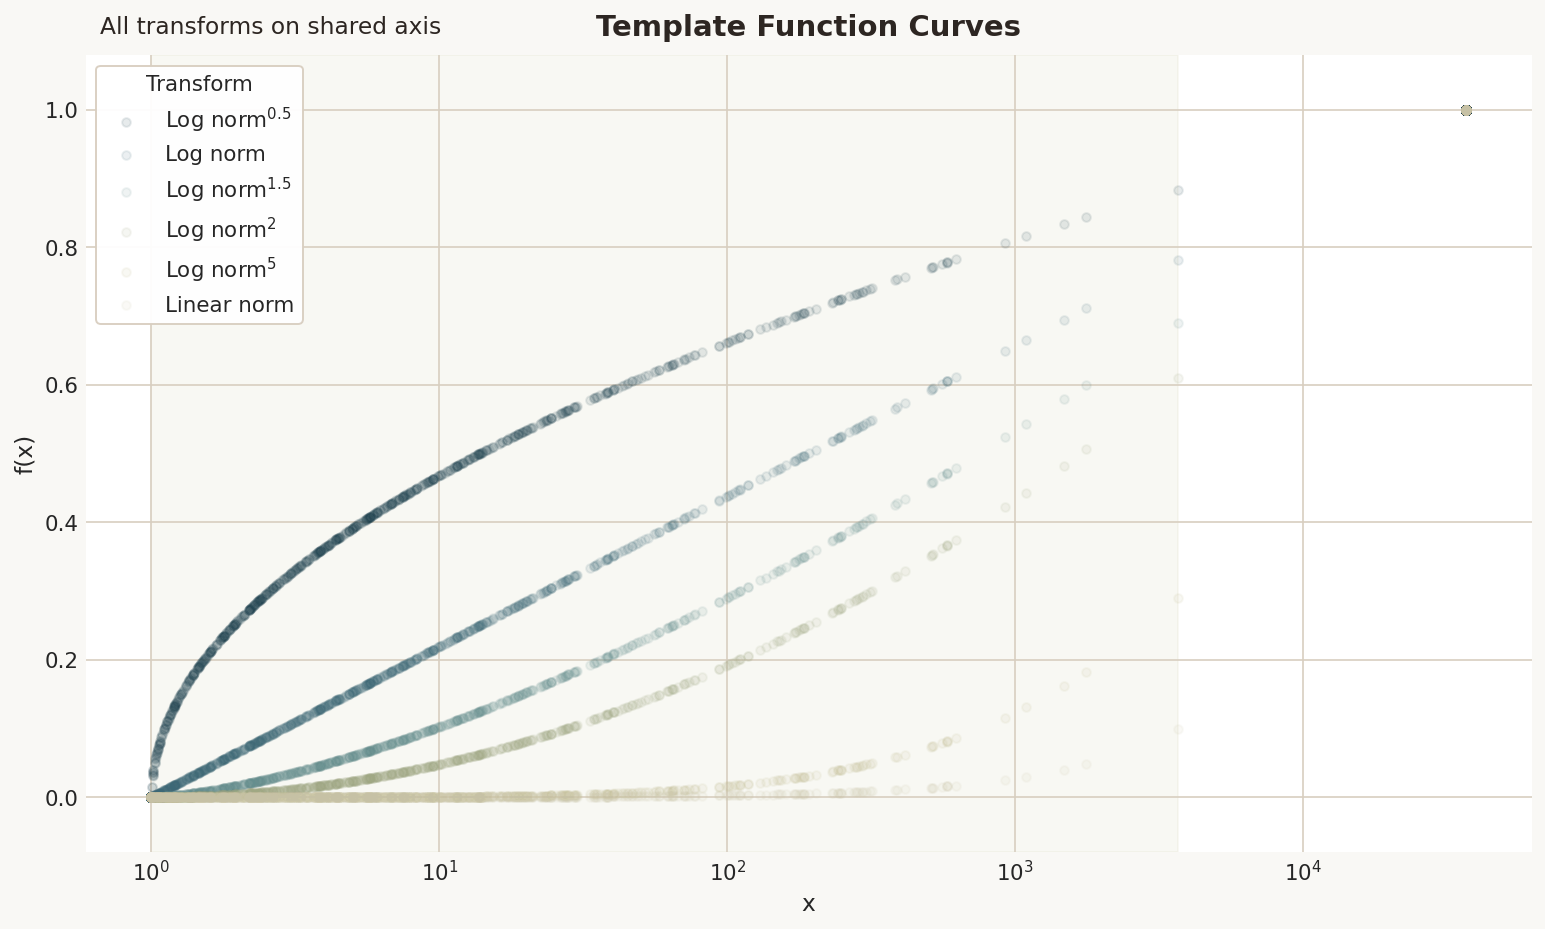

In [75]:
def func_norm(x):
    return (x - 1.0) / (36690.3 - 1.0)


def func_norm_log(x, p=1.0):
    norm_log = (np.log(x) - np.log(1.0)) / (np.log(36690.3) - np.log(1.0))
    return np.power(norm_log, p)


def func_sigmoid_log(x, s=1.0):
    sigmoid_shift = np.log(12.477)
    return 1.0 / (1.0 + np.exp(-(np.log(x) - sigmoid_shift) / s))


def plot_template_transform_curves(
    *,
    x_min=1.0,
    x_max=36690.3,
    n_points=600,
    shade_until=3669.03,
    figsize=(11.2, 6.8),
    title="Template Function Curves",
    x_label="x",
    y_label="f(x)",
    output_path=None,
):
    # x = np.logspace(np.log10(x_min), np.log10(x_max), n_points)
    # flatten them
    x = performance_df[ALGORITHMS].values.flatten()

    curves = {
        r"Log norm$^{0.5}$": func_norm_log(x, p=0.5),
        # r"Log norm$^{0.7}$": func_norm_log(x, p=0.7),
        "Log norm": func_norm_log(x),
        r"Log norm$^{1.5}$": func_norm_log(x, p=1.5),
        r"Log norm$^{2}$": func_norm_log(x, p=2.0),
        r"Log norm$^{5}$": func_norm_log(x, p=5.0),
        # r"Log norm$^{10}$": func_norm_log(x, p=10.0),
        "Linear norm": func_norm(x),
    }

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(PAPER_BG)
    ax.set_facecolor(AXIS_BG)

    # Lightly emphasize the low-budget region.
    shade_right = min(shade_until, x_max)
    if shade_right > x_min:
        ax.axvspan(
            x_min,
            shade_right,
            color=DARKER_PORTFOLIO_CMAP(0.82),
            alpha=0.1,
            zorder=0,
        )

    color_positions = [0.12, 0.34, 0.52, 0.68, 0.82, 0.92]
    for (label, y), pos in zip(curves.items(), color_positions):
        ax.scatter(
            x,
            y,
            label=label,
            color=DARKER_PORTFOLIO_CMAP(pos),
            marker="o",
            s=20,
            # solid_capstyle="round",
            alpha=0.1
        )

    ax.set_xscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=15, fontweight="semibold", pad=10)

    ax.text(
        0.01,
        1.02,
        "All transforms on shared axis",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=12,
        color=TEXT_COLOR,
    )

    ax.set_axisbelow(True)
    ax.grid(axis="both", color=GRID_COLOR, linewidth=1.0, alpha=0.85)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    y_all = np.concatenate([np.asarray(values, dtype=float) for values in curves.values()])
    y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)
    y_pad = 0.08 * (y_max - y_min if y_max > y_min else 1.0)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    legend = ax.legend(
        loc="upper left",
        frameon=True,
        facecolor=AXIS_BG,
        edgecolor=GRID_COLOR,
        fontsize=11,
        title="Transform",
        title_fontsize=11,
    )
    legend.get_frame().set_alpha(0.95)

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path)

    plt.show()


plot_template_transform_curves()

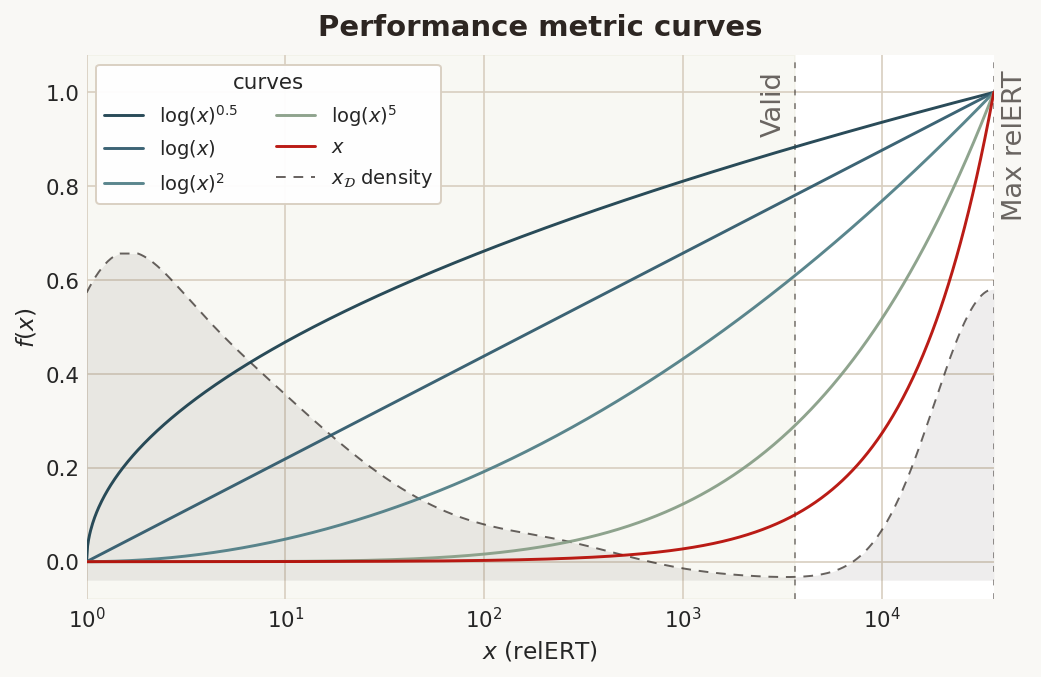

In [99]:
from matplotlib.transforms import blended_transform_factory
from scipy.stats import gaussian_kde


def _evaluate_log_density(values, x_grid, bw_method=0.16, clip_quantile=0.98):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    log_values = np.log10(values)

    kde = gaussian_kde(log_values, bw_method=bw_method)
    density = kde(np.log10(x_grid))

    positive_density = density[density > 0]
    if positive_density.size:
        scale = np.quantile(positive_density, clip_quantile)
        if scale <= 0:
            scale = positive_density.max()
        density = np.clip(density / scale, 0, 1)

    return density


def _plot_density_ridge(ax, x_grid, density, *, baseline=0.035, height=0.6):
    transform = blended_transform_factory(ax.transData, ax.transAxes)
    ridge_y = height * density + baseline

    ax.fill_between(
        x_grid,
        baseline,
        ridge_y,
        transform=transform,
        color=TEXT_COLOR,
        alpha=0.08,
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        x_grid,
        ridge_y,
        transform=transform,
        color=TEXT_COLOR,
        linewidth=1.0,
        linestyle=(0, (5, 4)),
        alpha=0.72,
        zorder=2,
        label=r"$x_\mathcal{D}$ density",
    )


def _add_reference_indicator(ax, x, label, *, text_side, line_style):
    indicator_transform = blended_transform_factory(ax.transData, ax.transAxes)
    ax.axvline(
        x,
        color=TEXT_COLOR,
        linewidth=1.0,
        linestyle=line_style,
        alpha=0.5,
        zorder=3,
    )
    x_offset = 4 if text_side == "right" else -4
    ha = "left" if text_side == "right" else "right"
    ax.annotate(
        label,
        xy=(x, 1.0),
        xycoords=indicator_transform,
        xytext=(x_offset, -8),
        textcoords="offset points",
        rotation=90,
        ha=ha,
        va="top",
        fontsize=14,
        color=TEXT_COLOR,
        alpha=0.7,
        clip_on=False,
    )


def plot_template_transform_curves_with_density_overlay(
    *,
    x_min=1.0,
    x_max=36690.3,
    curve_points=900,
    shade_until=3669.03,
    figsize=(7.6, 5),
    title="Performance metric curves",
    x_label=r"$x$ (relERT)",
    y_label=r"$f(x)$",
    output_path=None,
):
    x_grid = np.logspace(np.log10(x_min), np.log10(x_max), curve_points)
    observed_x = performance_df[ALGORITHMS].to_numpy(dtype=float).ravel()
    density = _evaluate_log_density(observed_x, x_grid)

    transform_defs = [
        (r"$\log(x)^{0.5}$", lambda x: func_norm_log(x, p=0.5)),
        (r"$\log(x)$", lambda x: func_norm_log(x)),
        # (r"$\log(x)^{1.5}$", lambda x: func_norm_log(x, p=1.5)),
        (r"$\log(x)^{2}$", lambda x: func_norm_log(x, p=2.0)),
        (r"$\log(x)^{5}$", lambda x: func_norm_log(x, p=5.0)),
        (r"$x$", lambda x: func_norm(x)),
    ]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(PAPER_BG)
    ax.set_facecolor(AXIS_BG)

    shade_right = min(shade_until, x_max)
    if shade_right > x_min:
        ax.axvspan(
            x_min,
            shade_right,
            color=DARKER_PORTFOLIO_CMAP(0.82),
            alpha=0.1,
            zorder=0,
        )

    _add_reference_indicator(
        ax,
        shade_until,
        "Valid",
        text_side="left",
        line_style=(0, (3, 4)),
    )
    _add_reference_indicator(
        ax,
        x_max,
        "Max relERT",
        text_side="right",
        line_style=(0, (3, 4)),
    )

    color_positions = [0.12, 0.28, 0.44, 0.62, 0.8, 0.92]
    y_all = []
    for (label, transform), pos in zip(transform_defs, color_positions):
        if label == r"$x$":
            color = "#B60D07"
        else:
            color = DARKER_PORTFOLIO_CMAP(pos)

        y = transform(x_grid)
        y_all.append(y)
        ax.plot(
            x_grid,
            y,
            label=label,
            color=color,
            linewidth=1.5,
            alpha=0.94,
            solid_capstyle="round",
            zorder=4,
        )

    _plot_density_ridge(ax, x_grid, density)

    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max+100)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=15, fontweight="semibold", pad=10)

    ax.set_axisbelow(True)
    ax.grid(axis="both", color=GRID_COLOR, linewidth=1.0, alpha=0.85)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    y_all = np.concatenate([np.asarray(values, dtype=float) for values in y_all])
    y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)
    y_pad = 0.08 * (y_max - y_min if y_max > y_min else 1.0)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    legend = ax.legend(
        loc="upper left",
        ncol=2,
        frameon=True,
        facecolor=AXIS_BG,
        edgecolor=GRID_COLOR,
        fontsize=10,
        title="curves",
        title_fontsize=11,
    )
    legend.get_frame().set_alpha(0.95)

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path)

    plt.show()


plot_template_transform_curves_with_density_overlay(output_path="analysis_outputs/performance_curves.pdf")